In [1]:
# import warnings is simply used to remove warnings about incompatibility with future Pandas update on Nate's device
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
from OnEL_func_run_all_functions import *
import pandas as pd
from ipynb.fs.defs.OnEL_working_file import (construct_calendar_year_list, 
                                            construct_business_case_year_list, 
                                            construct_operations_years_list, 
                                            construct_decomissioning_years_list, 
                                            construction_phase,
                                            operational_phase,
                                            decommissioning_phase,
                                            taxes_and_profits_part1,
                                            debt_and_loan_part1,
                                            taxes_and_profits_part2,
                                            debt_and_loan_part2,
                                            project_reserves,
                                            equity_funding,
                                            present_value_cashflows,
                                            cumulative_equity_and_debt_cashflows,
                                            discounted_cashflows_for_levelized_cost,
                                            levelized_cost_and_revenues,
                                            project_kpi,
                                            equity_kpi,
                                            output_kpi)
from OnEL_input_data import *
import importlib
import OnEL_input_data
from NSE_get_data_from_ESDL import *


XMLResource loading...
All variables saved to NSE_get_data_from_ESDL.pkl


Run the levelized cost and revenues function for all scenarios

In [3]:
file_names = ["TNVDW_cost_single_units_v1_pessimistic_scenario.esdl", "TNVDW_cost_single_units_v1_most_likely_scenario.esdl", "TNVDW_cost_single_units_v1_optimistic_scenario.esdl"]

# make a dataframe that will contain the levelized costs and revenues from all scenarios    
# Define the levels of the MultiIndex
groups = ['Pessimistic', 'Most likely', 'Optimistic']  # Group names
sub_columns = ['Costs', 'Revenues']  # Sub-column names

# Create the MultiIndex from the groups and sub_columns
multi_index = pd.MultiIndex.from_product([groups, sub_columns], names=['Scenario', 'Type'])

# Create an empty DataFrame with the multi-level columns
df_lcr_all_scenarios = pd.DataFrame(columns=multi_index)

# Make a dataframe that will contain all kpi results
df_kpi_results = pd.DataFrame(columns=['Pessimistic', 'Most likely', 'Optimistic', 'Unit'])


for x in file_names:

    esh = EnergySystemHandler()
    esh.load_file(x)
    energy_system = esh.get_energy_system()
    instance_list = energy_system.instance
    my_instance = instance_list[0]

    if x == file_names[0]:
        drop_scenarios = ['most_likely','optimistic']
    elif x == file_names[1]:
        drop_scenarios = ['pessimistic','optimistic']
    else: 
        drop_scenarios = ['pessimistic','most_likely']

    save_to_pickle(drop_scenarios, asset_parameters)

    importlib.reload(OnEL_input_data)


    onel_run_all_functions(OnEL_input_data.onel_capex_100mw,
                            OnEL_input_data.df_onel_opex_100mw,
                            OnEL_input_data.onel_inflation,
                            OnEL_input_data.onel_annual_electricity_costs_ppa,
                            OnEL_input_data.onel_annual_electricity_costs_grid,
                            OnEL_input_data.onel_electricity_grid_connection,
                            OnEL_input_data.onel_h2_storage_costs,
                            OnEL_input_data.onel_entry_tariff_h2_network, 
                            OnEL_input_data.onel_electricity_tax,
                            OnEL_input_data.df_stack_replacement_100mw,
                            OnEL_input_data.onel_h2_revenues,
                            OnEL_input_data.onel_hwi_revenues,
                            OnEL_input_data.onel_decommissioning_percentage,
                            OnEL_input_data.onel_loan_percentage,
                            OnEL_input_data.onel_loan_interest_rate,
                            OnEL_input_data.onel_income_tax_rate,
                            OnEL_input_data.onel_general_wacc,
                            OnEL_input_data.onel_lifetime)
    
    levelized_cost = levelized_cost_and_revenues(OnEL_input_data.onel_capex_100mw,
                                                OnEL_input_data.df_onel_opex_100mw,
                                                OnEL_input_data.onel_inflation,
                                                OnEL_input_data.onel_annual_electricity_costs_ppa,
                                                OnEL_input_data.onel_annual_electricity_costs_grid,
                                                OnEL_input_data.onel_electricity_grid_connection,
                                                OnEL_input_data.onel_h2_storage_costs,
                                                OnEL_input_data.onel_entry_tariff_h2_network,
                                                OnEL_input_data.onel_electricity_tax,
                                                OnEL_input_data.df_stack_replacement_100mw,
                                                OnEL_input_data.onel_h2_revenues,
                                                OnEL_input_data.onel_hwi_revenues,
                                                OnEL_input_data.onel_decommissioning_percentage,
                                                OnEL_input_data.onel_loan_percentage,
                                                OnEL_input_data.onel_loan_interest_rate,
                                                OnEL_input_data.onel_income_tax_rate,
                                                OnEL_input_data.onel_general_wacc,
                                                OnEL_input_data.onel_lifetime)

    project_result = project_kpi(OnEL_input_data.onel_capex_100mw,
                                OnEL_input_data.df_onel_opex_100mw,
                                OnEL_input_data.onel_inflation,
                                OnEL_input_data.onel_annual_electricity_costs_ppa,
                                OnEL_input_data.onel_annual_electricity_costs_grid,
                                OnEL_input_data.onel_electricity_grid_connection,
                                OnEL_input_data.onel_h2_storage_costs,
                                OnEL_input_data.onel_entry_tariff_h2_network,
                                OnEL_input_data.onel_electricity_tax,
                                OnEL_input_data.df_stack_replacement_100mw,
                                OnEL_input_data.onel_h2_revenues,
                                OnEL_input_data.onel_hwi_revenues,
                                OnEL_input_data.onel_decommissioning_percentage,
                                OnEL_input_data.onel_loan_percentage,
                                OnEL_input_data.onel_loan_interest_rate,
                                OnEL_input_data.onel_income_tax_rate,
                                OnEL_input_data.onel_general_wacc,
                                OnEL_input_data.onel_lifetime)

    equity_result = equity_kpi(OnEL_input_data.onel_capex_100mw,
                                OnEL_input_data.df_onel_opex_100mw,
                                OnEL_input_data.onel_inflation,
                                OnEL_input_data.onel_annual_electricity_costs_ppa,
                                OnEL_input_data.onel_annual_electricity_costs_grid,
                                OnEL_input_data.onel_electricity_grid_connection,
                                OnEL_input_data.onel_h2_storage_costs,
                                OnEL_input_data.onel_entry_tariff_h2_network,
                                OnEL_input_data.onel_electricity_tax,
                                OnEL_input_data.df_stack_replacement_100mw,
                                OnEL_input_data.onel_h2_revenues,
                                OnEL_input_data.onel_hwi_revenues,
                                OnEL_input_data.onel_decommissioning_percentage,
                                OnEL_input_data.onel_loan_percentage,
                                OnEL_input_data.onel_loan_interest_rate,
                                OnEL_input_data.onel_income_tax_rate,
                                OnEL_input_data.onel_general_wacc,
                                OnEL_input_data.onel_lifetime)

    output_result = output_kpi(OnEL_input_data.onel_capex_100mw,
                                OnEL_input_data.df_onel_opex_100mw,
                                OnEL_input_data.onel_inflation,
                                OnEL_input_data.onel_annual_electricity_costs_ppa,
                                OnEL_input_data.onel_annual_electricity_costs_grid,
                                OnEL_input_data.onel_electricity_grid_connection,
                                OnEL_input_data.onel_h2_storage_costs,
                                OnEL_input_data.onel_entry_tariff_h2_network, 
                                OnEL_input_data.onel_electricity_tax,
                                OnEL_input_data.df_stack_replacement_100mw,
                                OnEL_input_data.onel_h2_revenues,
                                OnEL_input_data.onel_hwi_revenues,
                                OnEL_input_data.onel_decommissioning_percentage,
                                OnEL_input_data.onel_loan_percentage,
                                OnEL_input_data.onel_loan_interest_rate,
                                OnEL_input_data.onel_income_tax_rate,
                                OnEL_input_data.onel_general_wacc,
                                OnEL_input_data.onel_lifetime)

    # create a temporary column of dummy data at the top-level of the MultiIndex (which will later be dropped)
    # without first creating this temporary column, pandas will not be able to assign values to the MultiIndex df
    df_lcr_all_scenarios.loc[:, 'temp'] = levelized_cost['cost']


    if x == file_names[0]:
        # add to pessimistic
        df_lcr_all_scenarios.loc[:, ('Pessimistic','Costs')] = levelized_cost['cost']
        df_lcr_all_scenarios.loc[:, ('Pessimistic','Revenues')] = levelized_cost['revenues'] 

        project_result_pes = project_result.drop(columns=['Unit'])
        project_result_pes.rename(columns={'Value':'Pessimistic'}, inplace=True)
        equity_result_pes = equity_result.drop(columns=['Unit'])
        equity_result_pes.rename(columns={'Value':'Pessimistic'}, inplace=True)
        output_result_pes = output_result.drop(columns=['Unit'])
        output_result_pes.rename(columns={'Value':'Pessimistic'}, inplace=True)

    elif x == file_names[1]:
        # add to most_likely
        df_lcr_all_scenarios.loc[:, ('Most likely','Costs')] = levelized_cost['cost']
        df_lcr_all_scenarios.loc[:, ('Most likely','Revenues')] = levelized_cost['revenues']

        project_result_ml = project_result.drop(columns=['Unit'])
        project_result_ml.rename(columns={'Value':'Most likely'}, inplace=True)
        equity_result_ml = equity_result.drop(columns=['Unit'])
        equity_result_ml.rename(columns={'Value':'Most likely'}, inplace=True)
        output_result_ml = output_result.drop(columns=['Unit'])
        output_result_ml.rename(columns={'Value':'Most likely'}, inplace=True)

    else: 
        # add to optimistic
        df_lcr_all_scenarios.loc[:, ('Optimistic','Costs')] = levelized_cost['cost']
        df_lcr_all_scenarios.loc[:, ('Optimistic','Revenues')] = levelized_cost['revenues']

        project_result_opt = project_result
        project_result_opt.rename(columns={'Value':'Optimistic'}, inplace=True)
        equity_result_opt = equity_result
        equity_result_opt.rename(columns={'Value':'Optimistic'}, inplace=True)
        output_result_opt = output_result
        output_result_opt.rename(columns={'Value':'Optimistic'}, inplace=True)

df_project_kpi_results = pd.concat([project_result_pes, project_result_ml, project_result_opt], axis=1)
df_equity_kpi_results = pd.concat([equity_result_pes, equity_result_ml, equity_result_opt], axis=1)
df_output_kpi_results = pd.concat([output_result_pes, output_result_ml, output_result_opt], axis=1)

project_kpi_row = pd.DataFrame({"Pessimistic":[""],"Most likely":[""],"Optimistic":[""], "Unit":[""]}, index=["Project KPI's"])
equity_kpi_row = pd.DataFrame({"Pessimistic":[""],"Most likely":[""],"Optimistic":[""], "Unit":[""]}, index=["Equity KPI's"])
output_kpi_row = pd.DataFrame({"Pessimistic":[""],"Most likely":[""],"Optimistic":[""], "Unit":[""]}, index=["Output KPI's"])

df_project_kpi_results = pd.concat([project_kpi_row, df_project_kpi_results], axis=0)
df_equity_kpi_results = pd.concat([equity_kpi_row, df_equity_kpi_results], axis=0)
df_output_kpi_results = pd.concat([output_kpi_row, df_output_kpi_results], axis=0)

df_kpi_results = pd.concat([df_project_kpi_results, df_equity_kpi_results, df_output_kpi_results], axis=0)

#return to most likely scenario
drop_scenarios = ['pessimistic','optimistic']
save_to_pickle(drop_scenarios, asset_parameters)

# drop temporary column that was only used for correct multi-level dataframe assignment        
df_lcr_all_scenarios = df_lcr_all_scenarios.drop(columns='temp')

df_lcr_all_scenarios

XMLResource loading...
All variables saved to NSE_get_data_from_ESDL.pkl
XMLResource loading...
All variables saved to NSE_get_data_from_ESDL.pkl
XMLResource loading...
All variables saved to NSE_get_data_from_ESDL.pkl
All variables saved to NSE_get_data_from_ESDL.pkl


C:\Users\DinaBoer\AppData\Local\Temp\ipykernel_9688\3242219211.py:193: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df_lcr_all_scenarios = df_lcr_all_scenarios.drop(columns='temp')


Scenario                    Pessimistic             Most likely              \
Type                              Costs    Revenues       Costs    Revenues   
capex                         95.356637         0.0   80.725026         0.0   
opex                          27.640859         0.0   22.606288         0.0   
purchase_electricity_ppa      73.282208         0.0   56.069565         0.0   
purchase_electricity_grid     12.961826         0.0     9.42917         0.0   
electricity_grid_connection   49.101744         0.0   50.219416         0.0   
h2_storage_costs               0.956481         0.0    1.381003         0.0   
entry_tariff_h2_network         3.59501         0.0    3.676841         0.0   
electricity_tax                3.900526         0.0    3.989311         0.0   
stack_replacement             20.656721         0.0   19.075811         0.0   
decommissioning                0.802378         0.0    0.476394         0.0   
interest_costs                19.636366         0.0   10.040138         0.0   
contingency                   10.222845         0.0    9.018421         0.0   
tax_expenses                   9.412289         0.0   16.972885         0.0   
h2_revenues                         0.0   78.794618         0.0   71.913534   
hwi_revenues                        0.0  187.787969         0.0  193.562958   
profits                             0.0         0.0         0.0         0.0   
unprofitable_gap                    0.0   60.943303         0.0   18.203776   

Scenario                    Optimistic              
Type                             Costs    Revenues  
capex                        41.464571         0.0  
opex                         16.265512         0.0  
purchase_electricity_ppa      55.45203         0.0  
purchase_electricity_grid     8.099614         0.0  
electricity_grid_connection  52.580597         0.0  
h2_storage_costs              1.587727         0.0  
entry_tariff_h2_network       3.849716         0.0  
electricity_tax               4.176878         0.0  
stack_replacement            14.072939         0.0  
decommissioning               0.363858         0.0  
interest_costs                2.646406         0.0  
contingency                   4.296077         0.0  
tax_expenses                 26.451781         0.0  
h2_revenues                        0.0   76.228559  
hwi_revenues                       0.0  204.234802  
profits                      49.155654         0.0  
unprofitable_gap                   0.0         0.0

All KPI's results

In [4]:
def clean_index_name(index):
    index = index.replace("_", " ")  # Replace underscores with spaces
    index = index.capitalize()  # Capitalize the first letter
    index = index.replace("kpi's", "KPI's")
    index = index.replace("EUR", "€")
    return index

# Apply the function to each index name
new_index_names = {index: clean_index_name(index) for index in df_kpi_results.index}

# Rename the index using the dictionary
df_kpi_results.rename(index=new_index_names, inplace=True)

# Change EUR to €
df_kpi_results['Unit'] = df_kpi_results['Unit'].replace({'Eur/MWh': '€/MWh', 'MEUR': '€'})

# Display the cleaned-up DataFrame
df_kpi_results.style.format(precision=2)


,Pessimistic,Most likely,Optimistic,Unit
Project KPI's,,,,
Net present value,-265.36,233.77,1525.42,€
Internal rate of return,6.47,11.74,19.61,%
Return on investment,48.04,190.67,533.46,%
Payback period,41.63,13.11,5.62,years
Discounted return on investment,-21.89,22.67,199.96,%
Discounted payback period,25.60,20.38,10.00,years
Equity KPI's,,,,
Net present value,-331.23,58.68,1031.75,€
Internal rate of return,3.22,10.30,18.02,%


In [5]:
# This can be used to copy the dataframe into Excel

df_kpi_results.to_clipboard()

Clean up column names to improve visualisation in the graph

In [6]:
# transpose dataframe to prepare for plotting
t_df_lcr_all_scenarios = df_lcr_all_scenarios.T

def clean_column_name(col):
    col = col.replace("_", " ")  # Replace underscores with spaces
    col = col.capitalize()  # Capitalize the first letter
    col = col.replace("Capex", "CAPEX")
    col = col.replace("Opex", "OPEX")
    col = col.replace("ppa", "PPA")
    col = col.replace("Hwi", "HWI")
    col = col.replace("h2", "H2")
    return col

# Apply the function to each column name
new_column_names = {col: clean_column_name(col) for col in t_df_lcr_all_scenarios.columns}

# Rename the columns using the dictionary
t_df_lcr_all_scenarios.rename(columns=new_column_names, inplace=True)

t_df_lcr_all_scenarios

CAPEX       OPEX Purchase electricity PPA  \
Scenario    Type                                                      
Pessimistic Costs     95.356637  27.640859                73.282208   
            Revenues        0.0        0.0                      0.0   
Most likely Costs     80.725026  22.606288                56.069565   
            Revenues        0.0        0.0                      0.0   
Optimistic  Costs     41.464571  16.265512                 55.45203   
            Revenues        0.0        0.0                      0.0   

                     Purchase electricity grid Electricity grid connection  \
Scenario    Type                                                             
Pessimistic Costs                    12.961826                   49.101744   
            Revenues                       0.0                         0.0   
Most likely Costs                      9.42917                   50.219416   
            Revenues                       0.0                         0.0   
Optimistic  Costs                     8.099614                   52.580597   
            Revenues                       0.0                         0.0   

                     H2 storage costs Entry tariff H2 network Electricity tax  \
Scenario    Type                                                                
Pessimistic Costs            0.956481                 3.59501        3.900526   
            Revenues              0.0                     0.0             0.0   
Most likely Costs            1.381003                3.676841        3.989311   
            Revenues              0.0                     0.0             0.0   
Optimistic  Costs            1.587727                3.849716        4.176878   
            Revenues              0.0                     0.0             0.0   

                     Stack replacement Decommissioning Interest costs  \
Scenario    Type                                                        
Pessimistic Costs            20.656721        0.802378      19.636366   
            Revenues               0.0             0.0            0.0   
Most likely Costs            19.075811        0.476394      10.040138   
            Revenues               0.0             0.0            0.0   
Optimistic  Costs            14.072939        0.363858       2.646406   
            Revenues               0.0             0.0            0.0   

                     Contingency Tax expenses H2 revenues HWI revenues  \
Scenario    Type                                                         
Pessimistic Costs      10.222845     9.412289         0.0          0.0   
            Revenues         0.0          0.0   78.794618   187.787969   
Most likely Costs       9.018421    16.972885         0.0          0.0   
            Revenues         0.0          0.0   71.913534   193.562958   
Optimistic  Costs       4.296077    26.451781         0.0          0.0   
            Revenues         0.0          0.0   76.228559   204.234802   

                        Profits Unprofitable gap  
Scenario    Type                                  
Pessimistic Costs           0.0              0.0  
            Revenues        0.0        60.943303  
Most likely Costs           0.0              0.0  
            Revenues        0.0        18.203776  
Optimistic  Costs     49.155654              0.0  
            Revenues        0.0              0.0

In [7]:
on_el_lc = t_df_lcr_all_scenarios
on_el_lc.to_pickle("on_el_lc.pkl")  # save the dataframe to a pickle file

Make graph

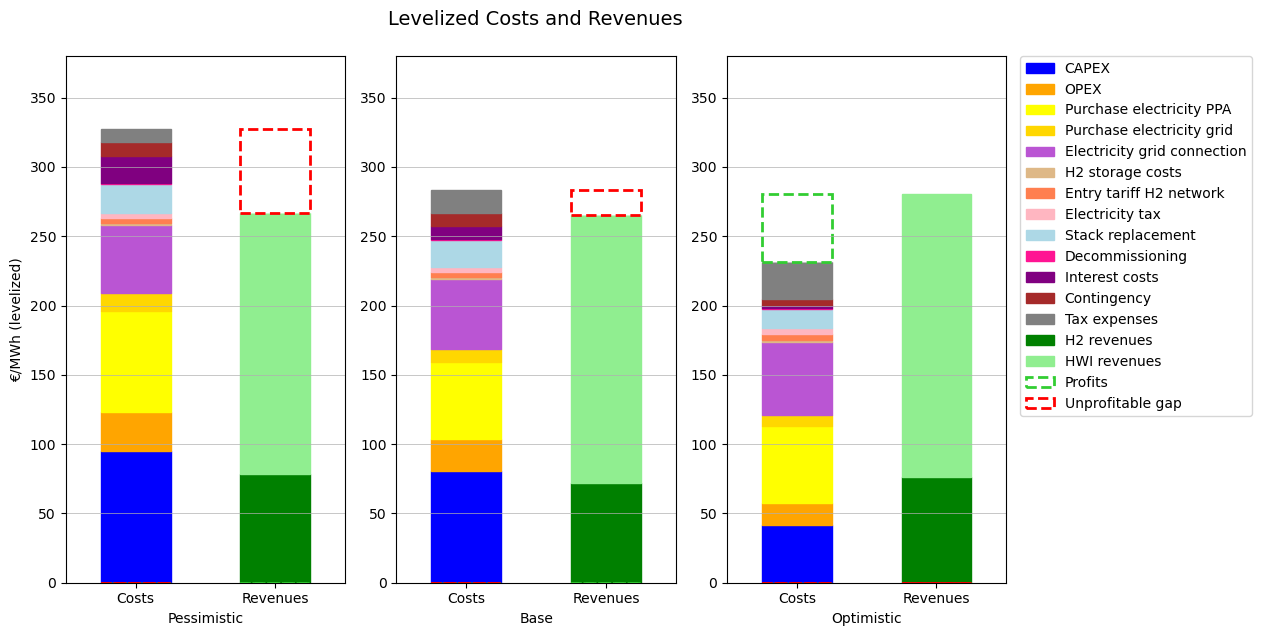

In [8]:
import matplotlib.pyplot as plt

# Define specific colors for each variable
color_mapping = {
    'CAPEX': 'blue',
    'OPEX': 'orange',
    'Purchase electricity PPA': 'yellow',
    'Purchase electricity grid': 'gold', 
    'Electricity grid connection': 'mediumorchid',
    'H2 storage costs': 'burlywood', 
    'Stack replacement': 'lightblue', 
    'Decommissioning': '#FF1493',
    'Interest costs': 'purple',
    'Contingency': 'brown',
    'Tax expenses': 'grey',
    'H2 revenues': 'green',
    'HWI revenues': 'lightgreen',  
    'Profits': 'limegreen',
    'Unprofitable gap': 'red',
    'Entry tariff H2 network': 'coral',
    'Electricity tax': 'lightpink',
}

# Plot levelized costs and revenues
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 6))
# plt.suptitle('Levelized Costs and Revenues')

# List of axes
axes = [ax1, ax2, ax3]

# Get column names
column_names = t_df_lcr_all_scenarios.columns

# Plot each scenario and apply custom colors
for ax, scenario in zip(axes, ['Pessimistic', 'Most likely', 'Optimistic']):
    xlabel = 'Base' if scenario == 'Most likely' else scenario
    plot = t_df_lcr_all_scenarios.loc[scenario].plot(
        kind='bar', stacked=True, ax=ax, rot='horizontal', legend=False,
        xlabel=xlabel, ylabel='€/MWh (levelized)' if ax == ax1 else None
    )
    
    # Iterate through bars and assign colors based on the variable name
    for i, bar in enumerate(ax.containers):
        for patch in bar:
            col_name = column_names[i]  # Get the corresponding column name
            
            if col_name == 'Unprofitable gap':  # Apply dashed line for 'Unprofitable gap'
                patch.set_edgecolor('red')  # Set edge color for the outline
                patch.set_linestyle('--')    # Set the edge line to dashed
                patch.set_linewidth(2)      # Make the dashed line thicker for visibility
                patch.set_facecolor('white')  # Set the fill color to white to only show outline
            elif col_name == "Profits":
                patch.set_edgecolor('limegreen')  # Set edge color for the outline
                patch.set_linestyle('--')    # Set the edge line to dashed
                patch.set_linewidth(2)      # Make the dashed line thicker for visibility
                patch.set_facecolor('white')  # Set the fill color to white to only show outline
            else:
                # Use the color mapping for other variables
                patch.set_color(color_mapping.get(col_name, 'gray'))  # Default to gray if not found

# Add a custom title above the "Most likely" plot
fig.text(0.36, 1.02, 'Levelized Costs and Revenues', ha='center', va='bottom', fontsize=14)


# Add a single legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Apply grid and y-limit to all axes
for ax in axes:
    ax.grid(True, which='major', axis='y', linestyle='-', linewidth=0.5)
    ax.set_ylim(0, 380)

plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust layout to make space for the legend
plt.show()
